In [1]:
import tensorflow as tf
import numpy as np
import random
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    balanced_accuracy_score
)

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    ReduceLROnPlateau,
    EarlyStopping,
    ModelCheckpoint,
    CSVLogger
)

I0000 00:00:1779969117.365666    5484 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779969117.565844    5484 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779969119.014017    5484 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
SEED = 26
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

In [3]:

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        try:
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
        except RuntimeError as e:
            print(f"GPU memory growth setting skipped: {e}")

In [4]:
import tensorflow as tf
print(tf.__version__)
print(tf.config.list_physical_devices())
print(tf.config.list_physical_devices('GPU'))

2.21.0
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy('mixed_float16')

In [6]:
IMAGE_SIZE = (224, 224)

BATCH_SIZE = 32

EPOCHS = 100

LEARNING_RATE = 0.0001

DATASET_PATH = "../PlantVillage_Dataset"

RESULTS_DIR = "results_3"

os.makedirs(RESULTS_DIR, exist_ok=True)

In [7]:
# train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(

#     rescale=1./255,

#     rotation_range=40,

#     zoom_range=[0, 0.3],

#     horizontal_flip=True,

#     vertical_flip=True,

#     validation_split=0.2
# )

# val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(

#     rescale=1./255,

#     validation_split=0.2
# )

In [8]:
# train_generator = train_datagen.flow_from_directory(

#     DATASET_PATH,

#     target_size=IMAGE_SIZE,

#     batch_size=BATCH_SIZE,

#     class_mode='categorical',

#     subset='training',

#     shuffle=True,

#     seed=SEED
# )

In [9]:
# val_generator = val_datagen.flow_from_directory(

#     DATASET_PATH,

#     target_size=IMAGE_SIZE,

#     batch_size=BATCH_SIZE,

#     class_mode='categorical',

#     subset='validation',

#     shuffle=False,

#     seed=SEED
# )

# CLASS_NAMES = list(train_generator.class_indices.keys())

# NUM_CLASSES = len(CLASS_NAMES)

# print("\nClasses:")
# print(CLASS_NAMES)

In [10]:
# print(train_generator.class_indices)

# from collections import Counter

# print("Train distribution:")
# print(Counter(train_generator.classes))

# print("Validation distribution:")
# print(Counter(val_generator.classes))

In [11]:
import os
import pandas as pd
import tensorflow as tf
from pathlib import Path
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications.resnet50 import preprocess_input

# Collect image paths and labels
DATASET_PATH = Path(DATASET_PATH)

image_paths = []
labels = []

for class_name in os.listdir(DATASET_PATH):
    class_dir = DATASET_PATH / class_name

    if class_dir.is_dir():
        for img in class_dir.iterdir():
            image_paths.append(str(img))
            labels.append(class_name)

# Stratified split
train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=SEED,
    shuffle=True
)

# DataFrames
train_df = pd.DataFrame({
    'filename': train_paths,
    'class': train_labels
})

val_df = pd.DataFrame({
    'filename': val_paths,
    'class': val_labels
})

# SAME augmentation as your original code
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=40,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip=True
)

val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# Generators
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='filename',
    y_col='class',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

val_generator = val_datagen.flow_from_dataframe(
    val_df,
    x_col='filename',
    y_col='class',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

CLASS_NAMES = list(train_generator.class_indices.keys())
NUM_CLASSES = len(CLASS_NAMES)

print("Classes:", CLASS_NAMES)
print("Train samples:", train_generator.samples)
print("Validation samples:", val_generator.samples)

Found 1721 validated image filenames belonging to 3 classes.
Found 431 validated image filenames belonging to 3 classes.
Classes: ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
Train samples: 1721
Validation samples: 431


In [12]:
base_model = ResNet50(

    weights='imagenet',

    include_top=False,

    input_shape=(224, 224, 3),

    pooling='avg'
)

I0000 00:00:1779969120.534689    5484 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4132 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [13]:
# base_model.trainable = False

In [14]:
# for layer in base_model.layers[:-40]:
#     layer.trainable = False

# for layer in base_model.layers[-40:]:
#     layer.trainable = True

In [15]:
x = base_model.output

outputs = Dense(
    NUM_CLASSES,
    activation='softmax'
)(x)

model = Model(
    inputs=base_model.input,
    outputs=outputs
)

In [16]:
optimizer = Adam(
    learning_rate=LEARNING_RATE
)

In [17]:
model.compile(

    optimizer=optimizer,

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,593,859 (90.00 MB)

 Trainable params: 23,540,739 (89.80 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [18]:
reduce_lr = ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.2,

    patience=3,

    verbose=1
)

early_stop = EarlyStopping(

    monitor='val_loss',

    patience=15,

    min_delta=0.001,

    restore_best_weights=True,

    verbose=1
)

checkpoint = ModelCheckpoint(

    filepath=os.path.join(
        RESULTS_DIR,
        "best.keras"
    ),

    monitor='val_accuracy',
    mode='max',

    save_best_only=True,

    verbose=1
)

csv_logger = CSVLogger(

    os.path.join(
        RESULTS_DIR,
        "training_log.csv"
    )
)

In [19]:
import tensorflow as tf

print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [20]:
history = model.fit(

    train_generator,

    validation_data=val_generator,

    epochs=EPOCHS,

    callbacks=[
        reduce_lr,
        early_stop,
        checkpoint,
        csv_logger
    ]
)

Epoch 1/100


I0000 00:00:1779969122.626986    5484 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1779969135.539269    5571 service.cc:153] XLA service 0x7a7c38043420 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779969135.539302    5571 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1779969135.961989    5571 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1779969140.078291    5571 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1779969140.509483    5571 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_49957__.614
I0000 00:00:1779969161.810033    5678 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_convert_

15/54 ━━━━━━━━━━━━━━━━━━━━ 6s 173ms/step - accuracy: 0.7186 - loss: 0.6053

I0000 00:00:1779969180.126769    5573 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_49957__.614
I0000 00:00:1779969197.520758    6772 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_195', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1779969198.215050    6774 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_convert_reduce_fusion_36', 16 bytes spill stores, 8 bytes spill loads

I0000 00:00:1779969199.128922    6774 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_199', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1779969206.310028    5573 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_convert_reduce_fusion_36', 16 bytes spill stores, 8 bytes spill loads
ptxas warning : Registers are spilled 

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 752ms/step - accuracy: 0.8645 - loss: 0.3081
Epoch 1: val_accuracy improved from None to 0.98608, saving model to results_3/best.keras
54/54 ━━━━━━━━━━━━━━━━━━━━ 100s 925ms/step - accuracy: 0.9500 - loss: 0.1255 - val_accuracy: 0.9861 - val_loss: 0.0390 - learning_rate: 1.0000e-04
Epoch 2/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.9853 - loss: 0.0304
Epoch 2: val_accuracy improved from 0.98608 to 0.99304, saving model to results_3/best.keras
54/54 ━━━━━━━━━━━━━━━━━━━━ 11s 202ms/step - accuracy: 0.9861 - loss: 0.0280 - val_accuracy: 0.9930 - val_loss: 0.0192 - learning_rate: 1.0000e-04
Epoch 3/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.9938 - loss: 0.0193
Epoch 3: val_accuracy improved from 0.99304 to 0.99768, saving model to results_3/best.keras
54/54 ━━━━━━━━━━━━━━━━━━━━ 12s 227ms/step - accuracy: 0.9959 - loss: 0.0148 - val_accuracy: 0.9977 - val_loss: 0.0089 - learning_rate: 1.0000e-04
Epoch 4/100
54/54 ━━━━━━━━━━━━━━━━━━

In [21]:
model.save(
    os.path.join(
        RESULTS_DIR,
        "final.keras"
    )
)

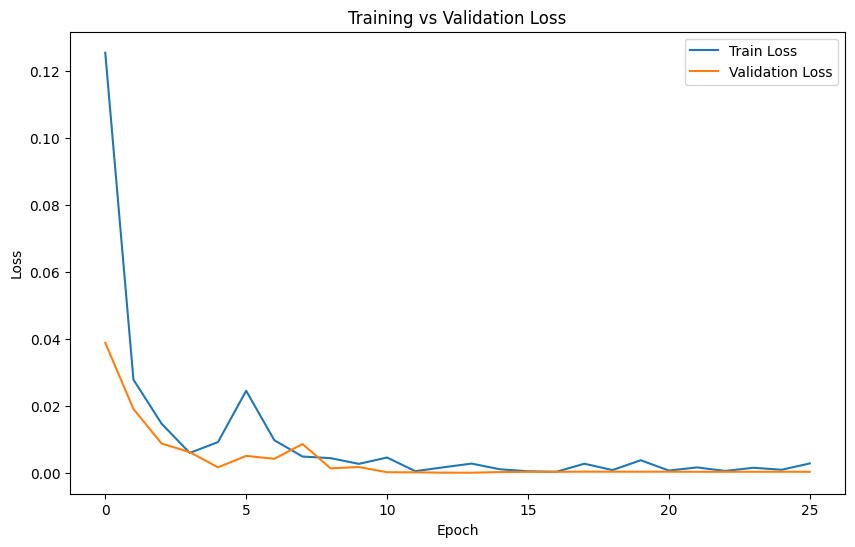

In [22]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history['loss'],
    label='Train Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.savefig(
    os.path.join(
        RESULTS_DIR,
        "loss_curve.png"
    )
)


In [23]:
plt.close()

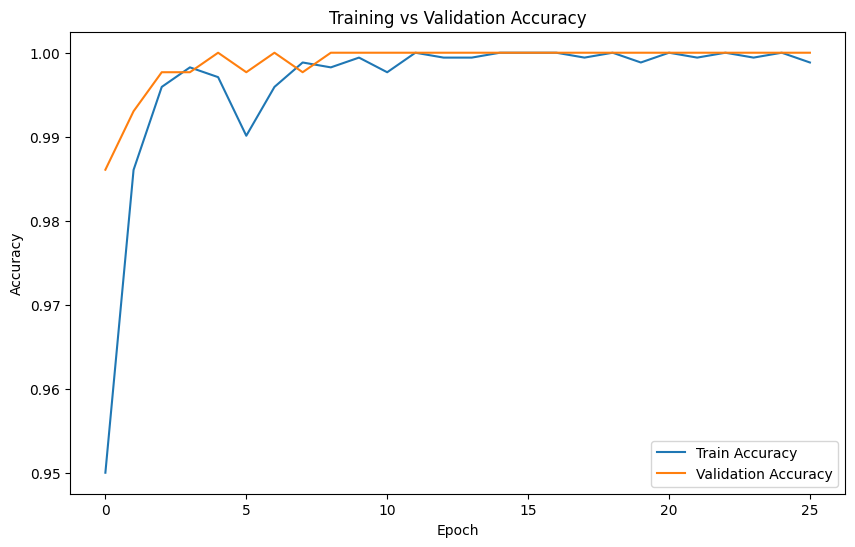

In [24]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.savefig(
    os.path.join(
        RESULTS_DIR,
        "accuracy_curve.png"
    )
)


In [25]:

plt.close()

In [26]:
print("\nEvaluating Model...\n")

val_generator.reset()

predictions = model.predict(val_generator)

y_pred = np.argmax(predictions, axis=1)

y_true = val_generator.classes


Evaluating Model...



E0000 00:00:1779969473.039045    5484 util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 247ms/step


In [27]:
accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

mcc = matthews_corrcoef(
    y_true,
    y_pred
)

balanced_acc = balanced_accuracy_score(
    y_true,
    y_pred
)

In [28]:
print("=" * 50)

print(f"Accuracy           : {accuracy*100:.2f}%")

print(f"Precision          : {precision*100:.2f}%")

print(f"Recall             : {recall*100:.2f}%")

print(f"F1 Score           : {f1*100:.2f}%")

print(f"MCC                : {mcc:.4f}")

print(f"Balanced Accuracy  : {balanced_acc*100:.2f}%")

print("=" * 50)


Accuracy           : 100.00%
Precision          : 100.00%
Recall             : 100.00%
F1 Score           : 100.00%
MCC                : 1.0000
Balanced Accuracy  : 100.00%


In [29]:
metrics = {

    "accuracy": float(accuracy),

    "precision": float(precision),

    "recall": float(recall),

    "f1_score": float(f1),

    "mcc": float(mcc),

    "balanced_accuracy": float(balanced_acc)
}

with open(
    os.path.join(
        RESULTS_DIR,
        "metrics.json"
    ),
    "w"
) as f:

    json.dump(
        metrics,
        f,
        indent=4
    )

In [30]:
report = classification_report(

    y_true,

    y_pred,

    target_names=CLASS_NAMES
)

print("\nClassification Report:\n")

print(report)

with open(
    os.path.join(
        RESULTS_DIR,
        "classification_report.txt"
    ),
    "w"
) as f:

    f.write(report)


Classification Report:

                       precision    recall  f1-score   support

Potato___Early_blight       1.00      1.00      1.00       200
 Potato___Late_blight       1.00      1.00      1.00       200
     Potato___healthy       1.00      1.00      1.00        31

             accuracy                           1.00       431
            macro avg       1.00      1.00      1.00       431
         weighted avg       1.00      1.00      1.00       431



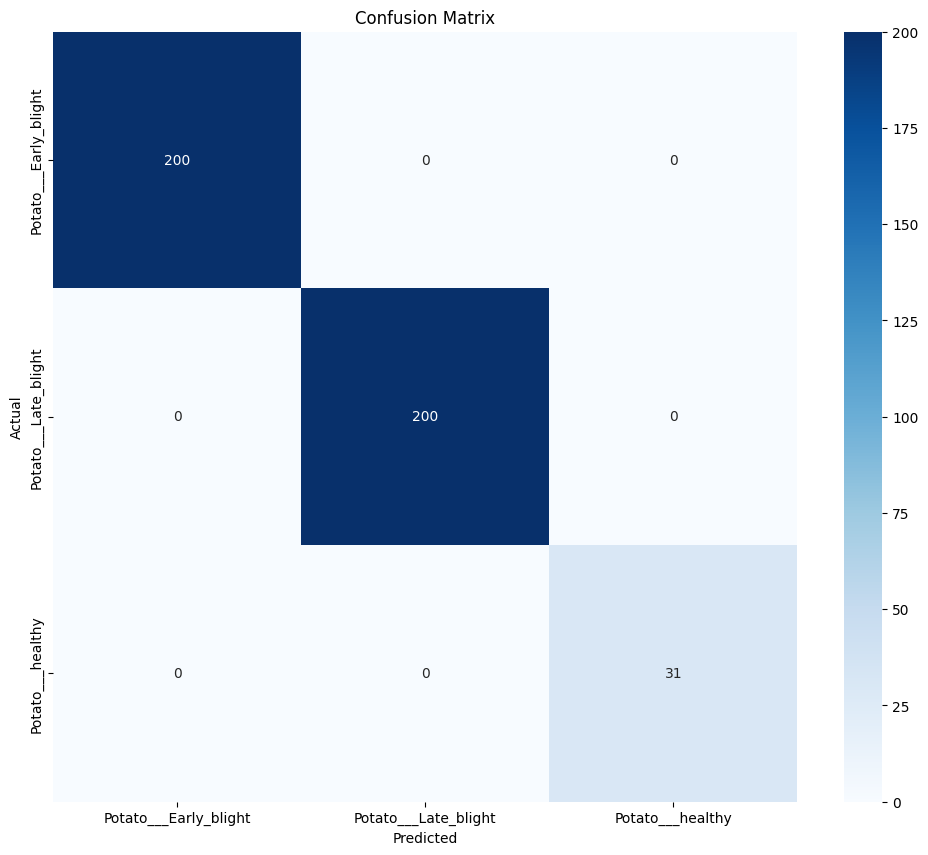

In [31]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=CLASS_NAMES,

    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.savefig(
    os.path.join(
        RESULTS_DIR,
        "confusion_matrix.png"
    )
)


In [32]:

plt.close()

In [33]:
history_dict = history.history

with open(
    os.path.join(
        RESULTS_DIR,
        "history.json"
    ),
    "w"
) as f:

    json.dump(
        history_dict,
        f,
        indent=4
    )

print("\nEverything saved in /results directory")

print("\nSaved Files:")

for file in os.listdir(RESULTS_DIR):
    print(" -", file)


Everything saved in /results directory

Saved Files:
 - final.keras
 - loss_curve.png
 - metrics.json
 - history.json
 - accuracy_curve.png
 - training_log.csv
 - confusion_matrix.png
 - best.keras
 - classification_report.txt
